Biological question

Do genetic perturbations propagate through the interactome as specific module-to-module compensation relationships, rather than as broad uniform activation of all chaperone-rich modules?

Main message

The earlier notebook using one combined chaperone score was too coarse.

Pairwise module-to-module analysis reveals structured response relationships.

Some modules behave as recurrent response / buffering modules.

Chaperone-rich modules are not interchangeable.

The strongest relationships can be followed back to specific genes.

In [1]:
# ============================================================
# CELL 2: IMPORTS AND HELPER FUNCTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def compute_module_averages(proteome_df, protein_to_module, modules):
    """
    Compute mean fold-change for each module across all deletions.
    """
    module_to_proteins = {m: [] for m in modules}

    for protein, module in protein_to_module.items():
        if module in module_to_proteins:
            module_to_proteins[module].append(protein)

    module_avgs = pd.DataFrame(index=proteome_df.index, columns=modules, dtype=float)

    for m in modules:
        prots = [p for p in module_to_proteins[m] if p in proteome_df.columns]
        if len(prots) > 0:
            module_avgs[m] = proteome_df[prots].mean(axis=1)
        else:
            module_avgs[m] = np.nan

    return module_avgs


def standardize_rows(df):
    """
    Z-score each row independently.
    Useful to compare relative module responses within each deletion module.
    """
    row_means = df.mean(axis=1)
    row_stds = df.std(axis=1).replace(0, np.nan)
    return df.sub(row_means, axis=0).div(row_stds, axis=0)

In [2]:
# ============================================================
# CELL 3: LOAD INTERACTOME + COMMUNITY MAP
# ============================================================

nodes_path = "../../18-finalize/processed-data/20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
community_map_path = "../../18-finalize/processed-data/community_map.pkl"

nodes_df = pd.read_pickle(nodes_path)
community_map = pd.read_pickle(community_map_path)

all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)

nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)

protein_to_module = {
    row["node"]: community_map.get(row["node"], None)
    for _, row in nodes_df.iterrows()
}

modules = sorted(set(community_map.values()))

print("Number of modules:", len(modules))
print("Number of chaperones in node table:", nodes_df["is_chaperone"].sum())

Number of modules: 30
Number of chaperones in node table: 66


In [4]:
# ============================================================
# CELL 4: LOAD CLEANED PROTEOME MATRIX
# ============================================================

proteome_matrix_path = "../../18-finalize/processed-data/yeast5k_fc_cleaned.pkl"
proteome_df = pd.read_pickle(proteome_matrix_path)

print("Proteome matrix shape:", proteome_df.shape)
print("First 10 deletions:", proteome_df.index[:10].tolist())
print("First 10 proteins:", proteome_df.columns[:10].tolist())

Proteome matrix shape: (2510, 1850)
First 10 deletions: ['YAL002W', 'YAL005C', 'YAL007C', 'YAL010C', 'YAL011W', 'YAL013W', 'YAL017W', 'YAL019W', 'YAL020C', 'YAL021C']
First 10 proteins: ['YPR010C-A', 'D6VTK4', 'O13297', 'O13516', 'O13563', 'O14455', 'O14467', 'YBR085C-A', 'O74700', 'P00128']


In [5]:
# ============================================================
# CELL 5: KEEP ONLY DELETIONS PRESENT IN COMMUNITY MAP
# ============================================================

valid_deletions = [orf for orf in proteome_df.index if orf in community_map]
proteome_df = proteome_df.loc[valid_deletions].copy()

print("Shape after restriction:", proteome_df.shape)

Shape after restriction: (2510, 1850)


In [6]:
# ============================================================
# CELL 6: COMPUTE MODULE-LEVEL RESPONSES
# ============================================================

module_avg_df = compute_module_averages(proteome_df, protein_to_module, modules)
module_avg_df["deletion_module"] = [community_map[orf] for orf in module_avg_df.index]

print(module_avg_df.shape)
module_avg_df.head()

(2510, 31)


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,deletion_module
orf,,,,,,,,,,,,,,,,,,,,,
YAL002W,1.439528,1.461760,0.929759,1.039678,1.012634,1.336118,NaN,NaN,0.998465,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL005C,0.953445,1.096046,1.064911,0.948788,0.960191,0.937099,NaN,NaN,1.042415,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL007C,1.030336,1.260866,0.955657,1.039014,1.088000,1.090821,NaN,NaN,1.171171,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
YAL010C,0.896672,0.938822,0.960594,0.933718,0.887217,0.979563,NaN,NaN,0.861362,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
YAL011W,0.984620,1.049097,1.066416,1.009443,0.861109,1.133766,NaN,NaN,1.069924,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [7]:
# ============================================================
# CELL 7: RAW MODULE-TO-MODULE RESPONSE MATRIX
# ============================================================

response_matrix = pd.DataFrame(index=modules, columns=modules, dtype=float)

for deletion_module in modules:
    subset = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    if len(subset) == 0:
        continue
    for target_module in modules:
        response_matrix.loc[deletion_module, target_module] = subset[target_module].mean()

response_matrix

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.000652,0.992577,0.990652,0.998026,0.997623,1.007639,NaN,NaN,0.990009,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.998948,0.994446,0.992416,1.002904,0.991265,1.015086,NaN,NaN,0.985788,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.988333,1.008342,0.978554,1.005433,0.954938,1.044973,NaN,NaN,1.012828,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.986951,0.977769,0.990133,0.988289,0.983705,0.995517,NaN,NaN,0.965952,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.981771,0.988051,0.995105,1.013119,0.967758,1.013473,NaN,NaN,1.005619,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.988943,1.013129,0.990882,1.000440,0.958671,0.990574,NaN,NaN,1.001518,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.011746,1.045377,0.967713,0.977337,1.050656,1.053737,NaN,NaN,0.972657,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.009079,1.006737,0.979906,0.996092,1.013814,1.030360,NaN,NaN,0.926964,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.013121,1.026892,0.993928,1.022034,1.006989,1.055177,NaN,NaN,0.947050,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.979524,1.020012,1.027298,0.999238,0.969373,0.983188,NaN,NaN,1.004218,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


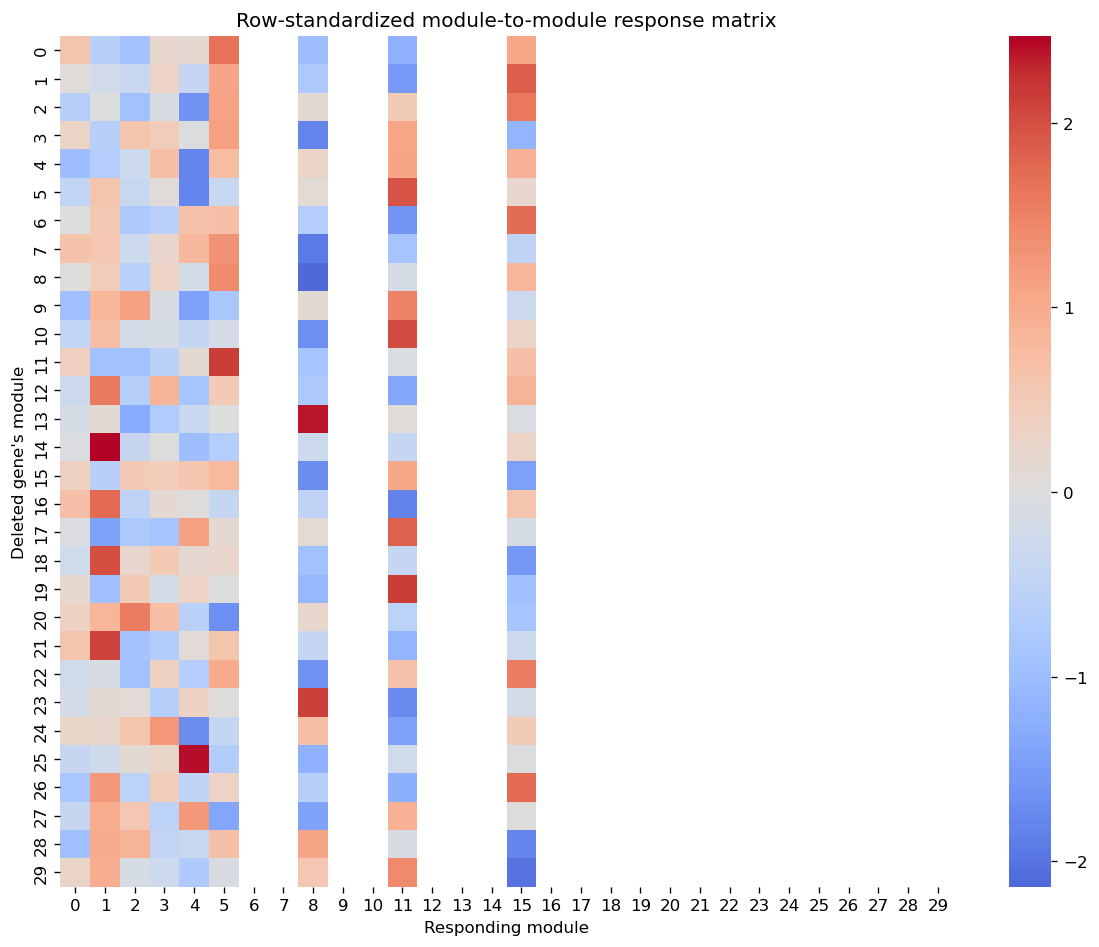

In [8]:
# ============================================================
# CELL 8: ROW-STANDARDIZED MODULE-TO-MODULE RESPONSE MATRIX
# ============================================================

response_matrix_z = standardize_rows(response_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(response_matrix_z, cmap="coolwarm", center=0)
plt.xlabel("Responding module")
plt.ylabel("Deleted gene's module")
plt.title("Row-standardized module-to-module response matrix")
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 9: CANDIDATE MODULE-TO-MODULE RELATIONSHIPS
# ============================================================

pairs = []

for deletion_module in modules:
    subset = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    if len(subset) == 0:
        continue

    for target_module in modules:
        if deletion_module == target_module:
            continue

        vals = subset[target_module].dropna()
        if len(vals) == 0:
            continue

        pairs.append({
            "deletion_module": deletion_module,
            "target_module": target_module,
            "mean_response": vals.mean(),
            "median_response": vals.median(),
            "n_deletions": len(vals)
        })

pairs_df = pd.DataFrame(pairs)

top_positive_pairs = pairs_df.sort_values("mean_response", ascending=False).head(20)
top_negative_pairs = pairs_df.sort_values("mean_response", ascending=True).head(20)

print("Top positive pairs:")
display(top_positive_pairs)

print("\nTop negative pairs:")
display(top_negative_pairs)

Top positive pairs:


,deletion_module,target_module,mean_response,median_response,n_deletions
136,16,1,1.305478,1.263430,6
181,21,1,1.246227,1.150402,4
220,25,4,1.228240,1.122880,4
169,19,11,1.221607,1.137011,5
204,23,8,1.196855,1.076680,4
154,18,1,1.167351,0.975950,5
259,29,11,1.150981,1.150981,1
135,16,0,1.148563,1.158187,6
143,16,15,1.141146,1.101208,6
101,12,1,1.131762,1.128793,9



Top negative pairs:


,deletion_module,target_module,mean_response,median_response,n_deletions
133,15,8,0.742498,0.658491,5
142,16,11,0.777808,0.802269,6
176,20,5,0.823909,0.877632,4
168,19,8,0.825308,0.794293,5
170,19,15,0.841055,0.836682,5
163,19,1,0.841687,0.813201,5
260,29,15,0.844963,0.844963,1
179,20,15,0.873846,0.975849,4
128,15,1,0.874084,0.967674,5
222,25,8,0.876917,1.000000,4


In [10]:
# ============================================================
# CELL 10: PAIRWISE STATISTICAL TESTS
# ============================================================

pair_stats = []

for deletion_module in modules:
    in_group = module_avg_df[module_avg_df["deletion_module"] == deletion_module]
    out_group = module_avg_df[module_avg_df["deletion_module"] != deletion_module]

    if len(in_group) < 5:
        continue

    for target_module in modules:
        if deletion_module == target_module:
            continue

        vals_in = in_group[target_module].dropna()
        vals_out = out_group[target_module].dropna()

        if len(vals_in) < 5 or len(vals_out) < 5:
            continue

        stat, p = mannwhitneyu(vals_in, vals_out, alternative="two-sided")

        pair_stats.append({
            "deletion_module": deletion_module,
            "target_module": target_module,
            "mean_in": vals_in.mean(),
            "mean_out": vals_out.mean(),
            "effect_size": vals_in.mean() - vals_out.mean(),
            "p_value": p,
            "n_in": len(vals_in),
            "n_out": len(vals_out)
        })

pair_stats_df = pd.DataFrame(pair_stats).sort_values("p_value")
pair_stats_df.head(30)

,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225
32,4,0,0.981771,0.996524,-0.014752,0.000116,209,2301
135,16,0,1.148563,0.994928,0.153635,0.000246,6,2504
20,2,5,1.044973,1.009221,0.035752,0.000325,285,2225
76,9,2,1.027298,0.989228,0.038070,0.000659,52,2458
31,3,15,0.972513,1.017874,-0.045361,0.001450,291,2219
3,0,4,0.997623,0.981359,0.016264,0.002797,711,1799
136,16,1,1.305478,0.997947,0.307530,0.004003,6,2504
170,19,15,0.841055,1.012958,-0.171903,0.007620,5,2505
56,6,15,1.115893,1.011534,0.104359,0.008143,26,2484


In [11]:
# ============================================================
# CELL 11: FDR CORRECTION
# ============================================================

pair_stats_df = pair_stats_df.copy()

reject, p_adj, _, _ = multipletests(pair_stats_df["p_value"], method="fdr_bh")

pair_stats_df["p_adj"] = p_adj
pair_stats_df["significant_fdr"] = reject

pair_stats_df = pair_stats_df.sort_values(["p_adj", "p_value"])
pair_stats_df.head(30)

,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out,p_adj,significant_fdr
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225,0.004443,True
32,4,0,0.981771,0.996524,-0.014752,0.000116,209,2301,0.010408,True
135,16,0,1.148563,0.994928,0.153635,0.000246,6,2504,0.014614,True
20,2,5,1.044973,1.009221,0.035752,0.000325,285,2225,0.014614,True
76,9,2,1.027298,0.989228,0.038070,0.000659,52,2458,0.023715,True
31,3,15,0.972513,1.017874,-0.045361,0.001450,291,2219,0.043486,True
3,0,4,0.997623,0.981359,0.016264,0.002797,711,1799,0.071915,False
136,16,1,1.305478,0.997947,0.307530,0.004003,6,2504,0.090076,False
170,19,15,0.841055,1.012958,-0.171903,0.007620,5,2505,0.146566,False
56,6,15,1.115893,1.011534,0.104359,0.008143,26,2484,0.146566,False


After FDR correction, your better-powered analysis still keeps four module-to-module relationships:

2 → 4 with negative effect

2 → 5 with positive effect

9 → 2 with positive effect

3 → 15 with negative effect

Do not center the story on 16 → 0 yet, even though it is significant, because effect is large but sample size is tiny (n_in = 6)

genetic perturbation responses are structured at the level of specific module-to-module relationships, not just broad global proteostasis activation.

In [12]:
# ============================================================
# CELL 12: FILTER TO BETTER-POWERED PAIRS
# ============================================================

# choose a threshold; you can tune later
min_n = 20
min_effect = 0.02

robust_pairs_df = pair_stats_df[
    (pair_stats_df["n_in"] >= min_n) &
    (pair_stats_df["effect_size"].abs() >= min_effect)
].copy()

robust_pairs_df = robust_pairs_df.sort_values(["p_adj", "effect_size"], ascending=[True, False])

print("Number of better-powered pairs:", len(robust_pairs_df))
robust_pairs_df.head(30)

Number of better-powered pairs: 42


,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out,p_adj,significant_fdr
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225,0.004443,True
20,2,5,1.044973,1.009221,0.035752,0.000325,285,2225,0.014614,True
76,9,2,1.027298,0.989228,0.038070,0.000659,52,2458,0.023715,True
31,3,15,0.972513,1.017874,-0.045361,0.001450,291,2219,0.043486,True
56,6,15,1.115893,1.011534,0.104359,0.008143,26,2484,0.146566,False
23,2,15,1.060659,1.006461,0.054198,0.013044,285,2225,0.187932,False
28,3,5,0.995517,1.015610,-0.020093,0.011606,291,2219,0.187932,False
21,2,8,1.012828,0.983101,0.029727,0.022421,285,2225,0.225784,False
94,11,2,0.959798,0.990284,-0.030486,0.021338,22,2488,0.225784,False
64,7,11,0.960861,0.999398,-0.038537,0.022578,87,2423,0.225784,False


The FDR-significant, better-powered pairs are:

2 → 4
effect = −0.035
p_adj = 0.0044

2 → 5
effect = +0.0358
p_adj = 0.0146

9 → 2
effect = +0.0381
p_adj = 0.0237

3 → 15
effect = −0.0454
p_adj = 0.0435

This is much better because:

module 2 has 285 deletions

module 3 has 291 deletions

module 9 has 52 deletions

a subset of interactome modules show reproducible pairwise perturbation-response relationships, with module 2 particularly prominent.

In [13]:
# ============================================================
# CELL 13: CHAPERONE-MODULE-FOCUSED PAIRS
# ============================================================

chaperone_modules = [0, 4, 7]

pair_stats_chap = pair_stats_df[
    pair_stats_df["target_module"].isin(chaperone_modules)
].copy()

pair_stats_chap = pair_stats_chap.sort_values(["p_adj", "effect_size"], ascending=[True, False])

pair_stats_chap.head(30)

,deletion_module,target_module,mean_in,mean_out,effect_size,p_value,n_in,n_out,p_adj,significant_fdr
19,2,4,0.954938,0.989940,-0.035002,0.000025,285,2225,0.004443,True
32,4,0,0.981771,0.996524,-0.014752,0.000116,209,2301,0.010408,True
135,16,0,1.148563,0.994928,0.153635,0.000246,6,2504,0.014614,True
3,0,4,0.997623,0.981359,0.016264,0.002797,711,1799,0.071915,False
44,5,4,0.958671,0.987762,-0.029091,0.033508,155,2355,0.242631,False
16,2,0,0.988333,0.996187,-0.007854,0.041463,285,2225,0.266550,False
57,7,0,1.009079,0.994800,0.014279,0.043226,87,2423,0.268300,False
52,6,4,1.050656,0.985289,0.065367,0.056062,26,2484,0.315351,False
48,6,0,1.011746,0.995123,0.016623,0.107584,26,2484,0.450351,False
148,17,4,1.063177,0.985781,0.077396,0.126945,6,2504,0.453876,False


In [19]:
# ============================================================
# CELL 14: WHICH MODULES RECUR AS RESPONSE MODULES?
# ============================================================

top_k = 30

response_module_counts = (
    pair_stats_df.head(top_k)["target_module"]
    .value_counts()
    .rename_axis("target_module")
    .reset_index(name="count_in_top_pairs")
)

response_module_counts


,target_module,count_in_top_pairs
0,11,6
1,0,4
2,5,4
3,15,4
4,4,3
5,1,3
6,8,3
7,2,2
8,3,1


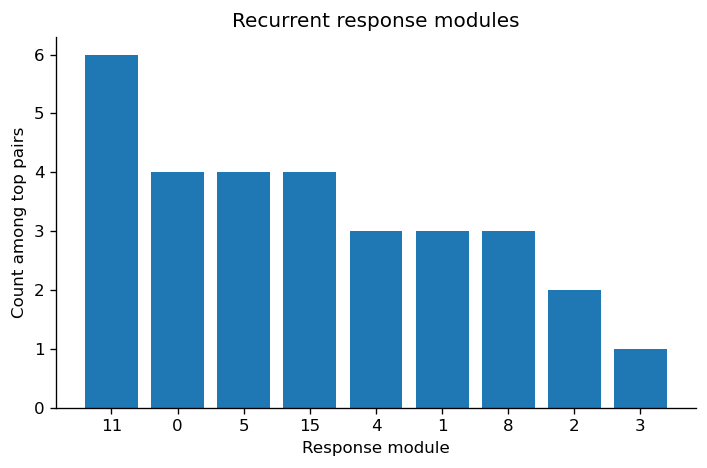

In [20]:
plt.figure(figsize=(6,4))
plt.bar(response_module_counts["target_module"].astype(str),
        response_module_counts["count_in_top_pairs"])
plt.xlabel("Response module")
plt.ylabel("Count among top pairs")
plt.title("Recurrent response modules")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 15: MODULE ANNOTATION TABLE
# ============================================================

module_annotation_df = pd.DataFrame({
    "module": modules,
    "putative_label": [""] * len(modules),
    "notes": [""] * len(modules)
})

module_annotation_df.head(15)

,module,putative_label,notes
0,0,,
1,1,,
2,2,,
3,3,,
4,4,,
5,5,,
6,6,,
7,7,,
8,8,,
9,9,,


In [17]:
# ============================================================
# CELL 16: GENE-LEVEL FOLLOW-UP
# ============================================================

focus_deletion_module = 11
focus_target_module = 5

subset = module_avg_df[module_avg_df["deletion_module"] == focus_deletion_module].copy()
subset = subset[[focus_target_module]].rename(columns={focus_target_module: "target_response"})
subset = subset.sort_values("target_response", ascending=False)

subset.head(20)

,target_response
orf,
YOR132W,1.389421
YJL053W,1.366974
YFR008W,1.307572
YJL154C,1.266313
YGR266W,1.201557
YOR069W,1.199026
YDR532C,1.188529
YHR114W,1.074014
YDR318W,1.067045


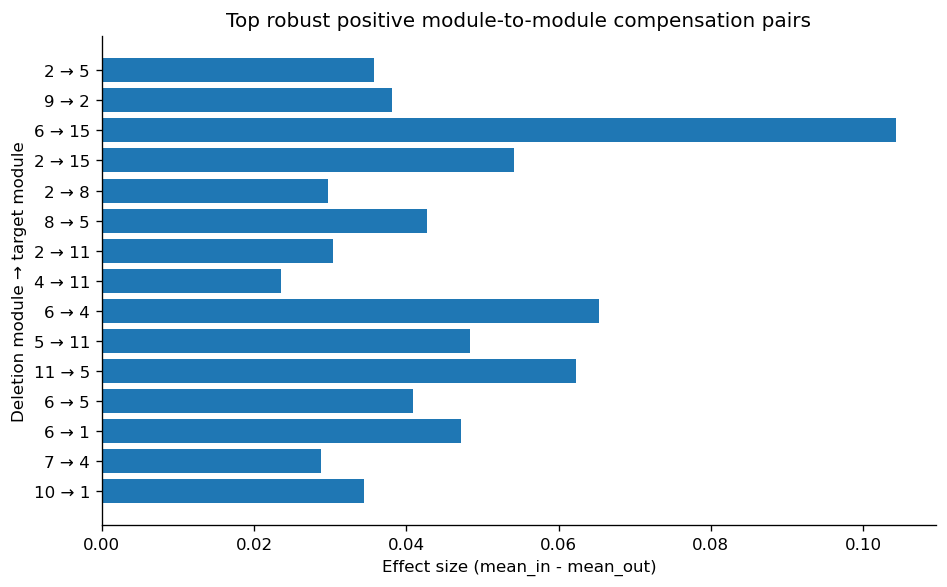

In [18]:
# ============================================================
# CELL 17: PLOT STRONGEST ROBUST POSITIVE PAIRS
# ============================================================

plot_df = robust_pairs_df[robust_pairs_df["effect_size"] > 0].head(15).copy()
plot_df["pair"] = plot_df["deletion_module"].astype(str) + " → " + plot_df["target_module"].astype(str)

plt.figure(figsize=(8,5))
plt.barh(plot_df["pair"], plot_df["effect_size"])
plt.xlabel("Effect size (mean_in - mean_out)")
plt.ylabel("Deletion module → target module")
plt.title("Top robust positive module-to-module compensation pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The first perturbation notebook showed that broad averaging across chaperone-rich modules obscured biologically meaningful structure. In contrast, pairwise module-to-module analysis reveals specific and statistically supported response relationships. In particular, perturbations originating in module 2 are associated with consistent decreases in module 4 and increases in module 5, while additional significant pairs link module 9 to module 2 and module 3 to module 15. These results suggest that perturbation buffering in the yeast interactome is selective and routed through specific module pairs rather than through uniform activation of all proteostasis-related communities.

In [22]:
# ============================================================
# CELL A1: BUILD MODULE MEMBERSHIP TABLE
# ============================================================

module_membership_df = pd.DataFrame({
    "node": list(community_map.keys()),
    "module": list(community_map.values())
})

# add extra annotations from nodes_df
extra_cols = ["node", "is_chaperone"]
available_cols = [c for c in extra_cols if c in nodes_df.columns]

module_membership_df = module_membership_df.merge(
    nodes_df[available_cols].drop_duplicates(),
    on="node",
    how="left"
)

module_membership_df.head()

,node,module,is_chaperone
0,YGL065C,0,False
1,YDR245W,0,False
2,YER183C,0,False
3,YGL137W,0,False
4,YJL172W,0,False


In [23]:
# ============================================================
# CELL A2: MODULE SIZE SUMMARY
# ============================================================

module_size_df = (
    module_membership_df.groupby("module")
    .agg(
        n_nodes=("node", "count"),
        n_chaperones=("is_chaperone", "sum")
    )
    .reset_index()
)

module_size_df["chaperone_fraction"] = module_size_df["n_chaperones"] / module_size_df["n_nodes"]
module_size_df.sort_values("n_nodes", ascending=False).head(15)

,module,n_nodes,n_chaperones,chaperone_fraction
0,0,1060,43,0.040566
1,1,636,2,0.003145
2,2,520,5,0.009615
3,3,453,1,0.002208
4,4,331,8,0.024169
5,5,275,0,0.000000
6,6,99,0,0.000000
7,7,98,6,0.061224
8,8,82,0,0.000000
9,9,67,0,0.000000


In [24]:
# ============================================================
# CELL A3: FOCUS MODULE LIST
# ============================================================

focus_modules = [0, 2, 4, 5, 9, 11, 15]

focus_membership_df = module_membership_df[module_membership_df["module"].isin(focus_modules)].copy()

for m in focus_modules:
    genes = focus_membership_df.loc[focus_membership_df["module"] == m, "node"].tolist()
    print(f"\nModule {m} | n = {len(genes)}")
    print(genes[:25])


Module 0 | n = 1060
['YGL065C', 'YDR245W', 'YER183C', 'YGL137W', 'YJL172W', 'YNL238W', 'YLR335W', 'YNL279W', 'YJL080C', 'YDR020C', 'YLR380W', 'YLR110C', 'YOR254C', 'YCL001W', 'YDR216W', 'YLR382C', 'YGR257C', 'YDR502C', 'YPL063W', 'YPL155C', 'YFR009W', 'YCR088W', 'YGL125W', 'YDL013W', 'YOR046C']

Module 2 | n = 520
['YOR095C', 'YGR002C', 'YJL140W', 'YDR224C;YBL002W', 'YBR090C', 'YPL169C', 'YNL215W', 'YKL009W', 'YOR116C', 'YOR061W', 'YNL031C', 'YPR010C', 'YML043C', 'YHR085W', 'YLL034C', 'YBR267W', 'YGL019W', 'YNL030W', 'YFL023W', 'YDL213C', 'YLR357W', 'YBR073W', 'YOR151C', 'YOR341W', 'YDL140C']

Module 4 | n = 331
['YLR203C', 'YKL220C', 'YBL074C', 'YOL096C', 'YLL041C', 'YDR235W', 'YDL043C', 'YJL023C', 'YLR090W', 'YFR016C', 'YER014W', 'YJL124C', 'YCL057W', 'YGR001C', 'YEL050C', 'YML110C', 'YPL135W', 'YLR089C', 'YBL037W', 'YNL005C', 'YDR088C', 'YPL107W', 'YGR255C', 'YPR094W', 'YHR024C']

Module 5 | n = 275
['YMR219W', 'YNL282W', 'YKR002W', 'YJR024C', 'YDR195W', 'YML092C', 'YDL147W', 'YDR2

In [25]:
# ============================================================
# CELL A5: EXPORT GENE LISTS FOR GO ENRICHMENT
# ============================================================

output_dir = "../../18-finalize/processed-data/module_gene_lists/"

import os
os.makedirs(output_dir, exist_ok=True)

for m in focus_modules:
    genes = (
        module_membership_df.loc[module_membership_df["module"] == m, "node"]
        .dropna()
        .astype(str)
        .sort_values()
        .tolist()
    )
    
    out_path = os.path.join(output_dir, f"module_{m}_genes.txt")
    
    with open(out_path, "w") as f:
        for g in genes:
            f.write(g + "\n")
    
    print("Saved:", out_path, "| n genes =", len(genes))

Saved: ../../18-finalize/processed-data/module_gene_lists/module_0_genes.txt | n genes = 1060
Saved: ../../18-finalize/processed-data/module_gene_lists/module_2_genes.txt | n genes = 520
Saved: ../../18-finalize/processed-data/module_gene_lists/module_4_genes.txt | n genes = 331
Saved: ../../18-finalize/processed-data/module_gene_lists/module_5_genes.txt | n genes = 275
Saved: ../../18-finalize/processed-data/module_gene_lists/module_9_genes.txt | n genes = 67
Saved: ../../18-finalize/processed-data/module_gene_lists/module_11_genes.txt | n genes = 43
Saved: ../../18-finalize/processed-data/module_gene_lists/module_15_genes.txt | n genes = 10
